In [1]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision.datasets as datasets
import torch.optim as optim

import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
class InceptionLayer(nn.Module):
    def __init__(self, in_channels, out_1x1, out_3x3_reduce, 
                 out_3x3, out_5x5_reduce, out_5x5, out_pool_proj):
        super().__init__()

        
        self.path1 = nn.Sequential(
            nn.Conv2d(in_channels, out_1x1, kernel_size=1),
            nn.BatchNorm2d(out_1x1),
            nn.ReLU()
        )

        self.path2 = nn.Sequential(
            nn.Conv2d(in_channels, out_3x3_reduce, kernel_size=1),
            nn.BatchNorm2d(out_3x3_reduce),
            nn.ReLU(),
            nn.Conv2d(out_3x3_reduce, out_3x3, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_3x3),
            nn.ReLU()
        )

        self.path3 = nn.Sequential(
            nn.Conv2d(in_channels, out_5x5_reduce, kernel_size=1),
            nn.BatchNorm2d(out_5x5_reduce),
            nn.ReLU(),
            nn.Conv2d(out_5x5_reduce, out_5x5, kernel_size=5, padding=2),
            nn.BatchNorm2d(out_5x5),
            nn.ReLU()
        )

        self.path4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, out_pool_proj, kernel_size=1),
            nn.BatchNorm2d(out_pool_proj),
            nn.ReLU()
        )

    def forward(self, x):
        p1 = self.path1(x)
        p2 = self.path2(x)
        p3 = self.path3(x)
        p4 = self.path4(x)

        return torch.cat([p1, p2, p3, p4], dim=1)

In [3]:
class GoogLeNet(nn.Module):
    def __init__(self, out_channels, in_channels=3, num_classes=1000):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=7, stride=2, padding=3)
        self.conv2 = nn.Conv2d(out_channels, 192, kernel_size=1, stride=1)
        self.conv3 = nn.Conv2d(192, 192, kernel_size=3, stride=1, padding=1)

        self.incep3a = InceptionLayer(192, out_1x1=64, out_3x3_reduce=96,
                                    out_3x3=128, out_5x5_reduce=16, out_5x5=32,
                                    out_pool_proj=32
                                    )
        self.incep3b = InceptionLayer(256, out_1x1=128, out_3x3_reduce=128, 
                                    out_3x3=192, out_5x5_reduce=32, out_5x5=96,
                                    out_pool_proj=64
                                    )
        
        self.incep4a = InceptionLayer(480, out_1x1=192, out_3x3_reduce=96, 
                                    out_3x3=208, out_5x5_reduce=16, out_5x5=48,
                                    out_pool_proj=64
                                    )
        self.incep4b = InceptionLayer(512, out_1x1=160, out_3x3_reduce=112, 
                                    out_3x3=224, out_5x5_reduce=24, out_5x5=64,
                                    out_pool_proj=64
                                    )
        self.incep4c = InceptionLayer(512, out_1x1=128, out_3x3_reduce=128, 
                                    out_3x3=256, out_5x5_reduce=24, out_5x5=64,
                                    out_pool_proj=64
                                    )
        self.incep4d = InceptionLayer(512, out_1x1=112, out_3x3_reduce=144, 
                                    out_3x3=288, out_5x5_reduce=32, out_5x5=64,
                                    out_pool_proj=64
                                    )
        self.incep4e = InceptionLayer(528, out_1x1=256, out_3x3_reduce=160, 
                                    out_3x3=320, out_5x5_reduce=32, out_5x5=128,
                                    out_pool_proj=128
                                    )
        
        self.incep5a = InceptionLayer(832, out_1x1=256, out_3x3_reduce=160, 
                                    out_3x3=320, out_5x5_reduce=32, out_5x5=128,
                                    out_pool_proj=128
                                    )
        self.incep5b = InceptionLayer(832, out_1x1=384, out_3x3_reduce=192, 
                                    out_3x3=384, out_5x5_reduce=48, out_5x5=128,
                                    out_pool_proj=128
                                    )
        
        self.auxclassifier1 = nn.Sequential(
            nn.AvgPool2d(kernel_size=5, stride=3),
            nn.Conv2d(512, 128, kernel_size=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(128, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, num_classes)
        )

        self.auxclassifier2 = nn.Sequential(
            nn.AvgPool2d(kernel_size=5, stride=3),
            nn.Conv2d(528, 128, kernel_size=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(128, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, num_classes)
        )

        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.localnorm = nn.LocalResponseNorm(5, 0.0001, 0.75, 2)
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Dropout(0.4),
            nn.Flatten(),
            nn.Linear(1024, num_classes),
        )

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.maxpool(x)
        x = self.localnorm(x)
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.localnorm(x)
        x = self.maxpool(x)
        x = self.incep3b(self.incep3a(x))
        x = self.maxpool(x)
        x = self.incep4a(x)
        aux1 = self.auxclassifier1(x)
        x = self.incep4b(x)
        x = self.incep4c(x)
        x = self.incep4d(x)
        aux2 = self.auxclassifier2(x)
        x = self.incep4e(x)
        x = self.maxpool(x)
        x = self.incep5b(self.incep5a(x))
        x = self.classifier(x)

        if self.training:
            return x, aux1, aux2
        return x

In [4]:
def train_epoch(model, loader, criterion, optimizer, epoch, num_epochs=10):
    model.train()
    running_loss, total, correct = 0.0, 0, 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        output, aux1, aux2 = model(images)
        loss = criterion(output, labels) + 0.3 * criterion(aux1, labels) + 0.3 * criterion(aux2, labels)
        loss.backward()
        optimizer.step()

        # Tracking the loss and accuracy
        running_loss += loss.item() * images.size(0)
        pred = output.argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

        if batch_idx % 500 == 0:
            print(f"Epoch: {epoch}/{num_epochs}")
            print(f"Step: {batch_idx+1}/{len(loader)}")
            print(f"Loss: {running_loss / total}")

    accuracy = correct / total
    avg_loss = running_loss / total

    return avg_loss, accuracy

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, total, correct = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        output = model(images)
        loss = criterion(output, labels)

        running_loss += loss.item() * images.size(0)
        pred = output.argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [5]:
def train(model, train_loader, test_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):
    model.train()
    train_loss, val_loss, train_accuracy, val_accuracy = [], [], [], []
    best_val_acc = 0.0
    
    for epoch in range(1, num_epochs+1):
        t_loss, t_acc = train_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            epoch,
            num_epochs
        ) 
        v_loss, v_acc = evaluate(
            model, 
            test_loader,
            criterion
        )

        scheduler.step()

        train_loss.append(t_loss)
        train_accuracy.append(t_acc)
        val_loss.append(v_loss)
        val_accuracy.append(v_acc)

        print(f"Train loss: {t_loss} | Train accuracy: {t_acc}")
        print(f"Validation loss: {v_loss} | Validation accuracy: {v_acc}")

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            torch.save(model.state_dict(), 'GoogLeNet_Testing.pth')
            print(f"New best model saved: (val accuracy: {best_val_acc})")

    # Test on the final validation set
    model.eval()
    
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            output = model(images)
            loss = criterion(output, labels)\
        
            running_loss += loss.item() * images.size(0)
            pred = output.argmax(dim=1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
        
        cross_val_acc = correct / total
        cross_val_loss = running_loss / total
        print(f"Final validation loss and accuracy:\nLoss: {cross_val_loss}\nAccuracy: {cross_val_acc}")
        torch.save(model.state_dict(), 'GoogLeNet_CrossVal.pth')
        print(f"Final cross-validation model saved: (val accuracy: {cross_val_acc})")

    return train_loss, val_loss, train_accuracy, val_accuracy 

In [6]:
import matplotlib.pyplot as plt

def training_metrics(train_losses, val_losses, train_accuracy, val_accuracy):
    epochs = range(1, len(train_losses) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Loss plot
    ax1.plot(epochs, train_losses, label="Train loss")
    ax1.plot(epochs, val_losses, label="Val Loss")
    ax1.set_title("Training and Validation Loss")
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Accuracy plot
    ax2.plot(epochs, train_accuracy, label="Train Accuracy")
    ax2.plot(epochs, val_accuracy, label="Val Accuracy")
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.savefig('trainingmetrics.png')
    plt.show()

In [ ]:
def get_dataloaders(batch_size=32):
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225])
    ])

    test_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225])
    ])

    train_set = datasets.CIFAR100('./data', train=True, download=True, transform=train_transform)
    test_data = datasets.CIFAR100('./data', train=False, download=True, transform=test_transform)
    train_data, val_data = random_split(train_set, [45000, 5000])

    train_loader = DataLoader(
        dataset=train_data,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )

    test_loader = DataLoader(
        dataset=test_data,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    val_loader = DataLoader(
        dataset=val_data,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    return train_loader, test_loader, val_loader
    

Epoch: 1/50
Step: 1/1407
Loss: 7.458069801330566
Epoch: 1/50
Step: 501/1407
Loss: 7.168758243857743
Epoch: 1/50
Step: 1001/1407
Loss: 7.0284715956384005
Train loss: 6.952700717756484 | Train accuracy: 0.06048888888888889
Validation loss: 3.727488637161255 | Validation accuracy: 0.1264
New best model saved: (val accuracy: 0.1264)
Epoch: 2/50
Step: 1/1407
Loss: 6.551701545715332
Epoch: 2/50
Step: 501/1407
Loss: 6.638952738748577
Epoch: 2/50
Step: 1001/1407
Loss: 6.591340742863856
Train loss: 6.547411651187473 | Train accuracy: 0.10602222222222223
Validation loss: 3.4412379009246825 | Validation accuracy: 0.1776
New best model saved: (val accuracy: 0.1776)
Epoch: 3/50
Step: 1/1407
Loss: 6.581506729125977
Epoch: 3/50
Step: 501/1407
Loss: 6.358476694948421
Epoch: 3/50
Step: 1001/1407
Loss: 6.320171585807076
Train loss: 6.286188810984294 | Train accuracy: 0.13535555555555556
Validation loss: 3.2735699081420897 | Validation accuracy: 0.2057
New best model saved: (val accuracy: 0.2057)
Epoch: 

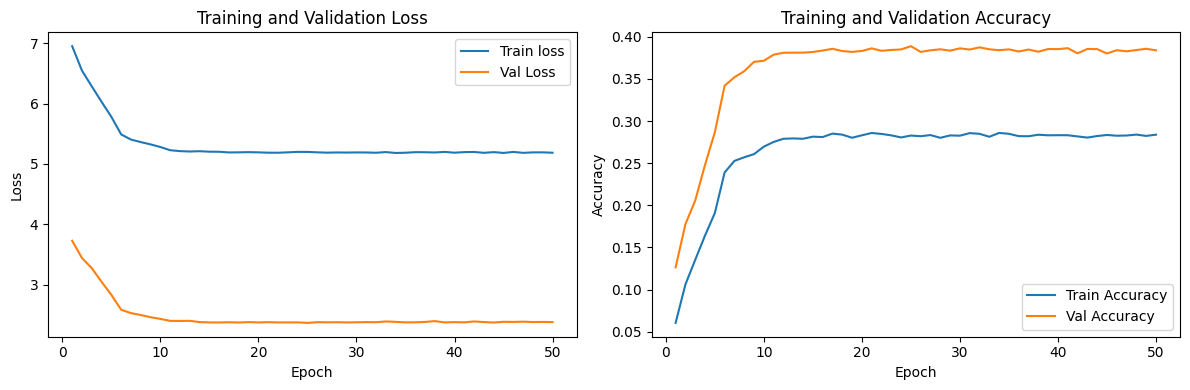

In [8]:
def main():
    model = GoogLeNet(out_channels=64, num_classes=100).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

    train_loader, test_loader, val_loader = get_dataloaders(batch_size=32)

    train_loss, val_loss, train_acc, val_acc = train(
        model, 
        train_loader, 
        test_loader, 
        val_loader,
        criterion,
        optimizer,
        scheduler,
        num_epochs=20
    )

    print("Training completed")

    training_metrics(train_loss, val_loss, train_acc, val_acc)
    
if __name__ == "__main__":
    main()